# Summary of Weather

In [1]:
# Data manipulation and numerical operations
import pandas as pd
import numpy as np


In [2]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


In [4]:
# Load the dataset
df = pd.read_csv('3_Summary of Weather.csv')
print("First Five Rows")
df.head()

First Five Rows


C:\Users\User\AppData\Local\Temp\ipykernel_7824\4183748372.py:2: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('3_Summary of Weather.csv')


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,7/1/1942,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,7/2/1942,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,7/3/1942,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,7/4/1942,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,7/5/1942,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Preprocessing

In [5]:
#Print Basic Information
print("\nDataset Info: ")
df.info()


Dataset Info: 
<class 'pandas.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  str    
 2   Precip       119040 non-null  str    
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  str    
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877

In [6]:
#To undertsand the distribution of numerical data
#To observe mean, minimum, maximum and srandard deviation
# To identify unusual values or possible outliers
print("\nStatistical Summary:")
print(df.describe())




Statistical Summary:
                 STA  WindGustSpd        MaxTemp        MinTemp  \
count  119040.000000   532.000000  119040.000000  119040.000000   
mean    29659.435795    37.774534      27.045111      17.789511   
std     20953.209402    10.297808       8.717817       8.334572   
min     10001.000000    18.520000     -33.333333     -38.333333   
25%     11801.000000    29.632000      25.555556      15.000000   
50%     22508.000000    37.040000      29.444444      21.111111   
75%     33501.000000    43.059000      31.666667      23.333333   
max     82506.000000    75.932000      50.000000      34.444444   

            MeanTemp             YR             MO             DA          DR  \
count  119040.000000  119040.000000  119040.000000  119040.000000  533.000000   
mean       22.411631      43.805284       6.726016      15.797530   26.998124   
std         8.297982       1.136718       3.425561       8.794541   15.221732   
min       -35.555556      40.000000       1.000000

In [7]:
# Display the initial shape of the dataset
print("Initial dataset shape: ",df.shape)

Initial dataset shape:  (119040, 31)


In [8]:
# Replace string 'T' with 0 and force the whole column into float type
df['Precip'] = df['Precip'].replace('T', 0)
df['Precip'] = pd.to_numeric(df['Precip'], errors='coerce')
print(df['Precip'])

0         1.016
1         0.000
2         2.540
3         2.540
4         0.000
          ...  
119035    0.000
119036    9.906
119037    0.000
119038    0.000
119039    0.000
Name: Precip, Length: 119040, dtype: float64


In [9]:
# Convert Date column to datetime safely & extract time components
#Converts text dates into a proper datetime format.
#Extracting year, month, and day allows the model to capture seasonal and time-based weather patterns.
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

In [10]:
#Removes non-numeric values.
#Ensures rainfall measurements are standardized for calculations and analysis.
df['PRCP'] = df['PRCP'].replace('T', 0)
df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')

In [11]:
# Drop columns that are completely or mostly empty
#Columns with too many missing values provide little useful information.
#Removing them reduces noise and improves model efficiency.
#Makes the dataset easier to manage.
cols_to_drop = [
    'FT', 'FB', 'FTI', 'ITH', 'SD3', 'RHX', 'RHN', 'RVG', 'WTE', 
    'WindGustSpd', 'DR', 'SPD', 'PGT', 'SND', 'PoorWeather', 'TSHDSBRSGF'
]
df = df.drop(columns=cols_to_drop, errors='ignore')

In [12]:
#Drop explicit row duplicates
df = df.drop_duplicates()

In [13]:
#Remove Missing Values in Important Columns
df = df.dropna(subset=['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip'])
print("Cleaned Dataset Shape:", df.shape)

Cleaned Dataset Shape: (119030, 18)


# EDA

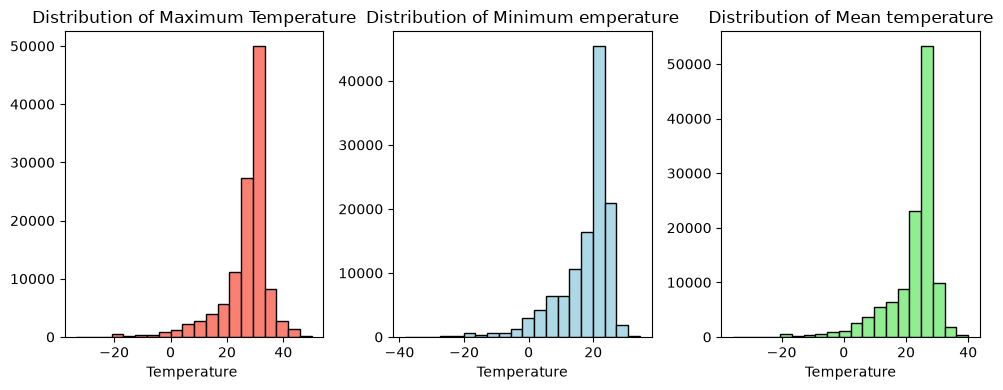

In [15]:
 #Temperature distributions
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

# Temperature distributions
axes[0].hist(df['MaxTemp'], bins=20, color='salmon', edgecolor='black')
axes[0].set_title('Distribution of Maximum Temperature')
axes[0].set_xlabel('Temperature ')

axes[1].hist(df['MinTemp'], bins=20, color='lightblue', edgecolor='black')
axes[1].set_title('Distribution of Minimum emperature')
axes[1].set_xlabel('Temperature')

axes[2].hist(df['MeanTemp'], bins=20, color='lightgreen', edgecolor='black')
axes[2].set_title('Distribution of Mean temperature')
axes[2].set_xlabel('Temperature')

plt.tight_layout()

plt.savefig("temperature_distributions.png",
            dpi=300, 
            bbox_inches="tight")

plt.show()

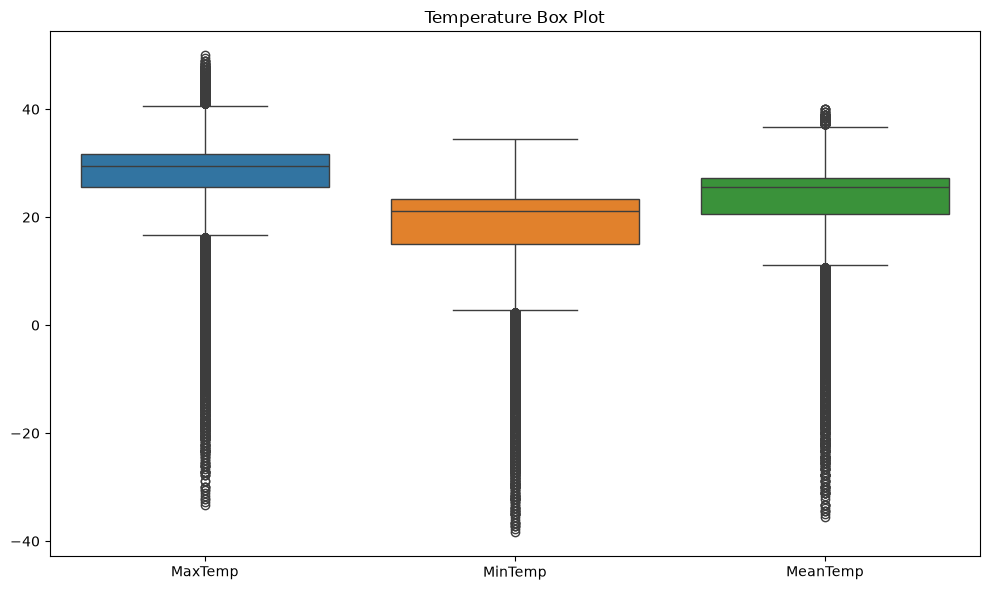

In [16]:
# Box plots for temperature
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['MaxTemp', 'MinTemp', 'MeanTemp']])
plt.title('Temperature Box Plot')
plt.tight_layout()

plt.savefig("temperature_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

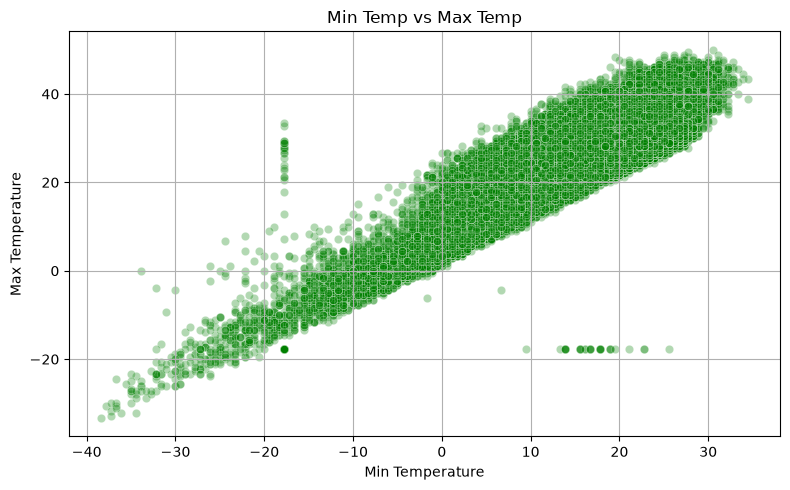

In [17]:
# Visual 3: Relationship Between Min and Max Temperature
plt.figure(figsize=(8, 5))
sns.scatterplot(x='MinTemp', y='MaxTemp', data=df, alpha=0.3, color='green')
plt.title('Min Temp vs Max Temp')
plt.xlabel('Min Temperature')
plt.ylabel('Max Temperature')
plt.tight_layout()
plt.grid(True)
plt.tight_layout()

plt.savefig("min temp vs max temp .png",
            dpi=300,
            bbox_inches="tight")

plt.show()

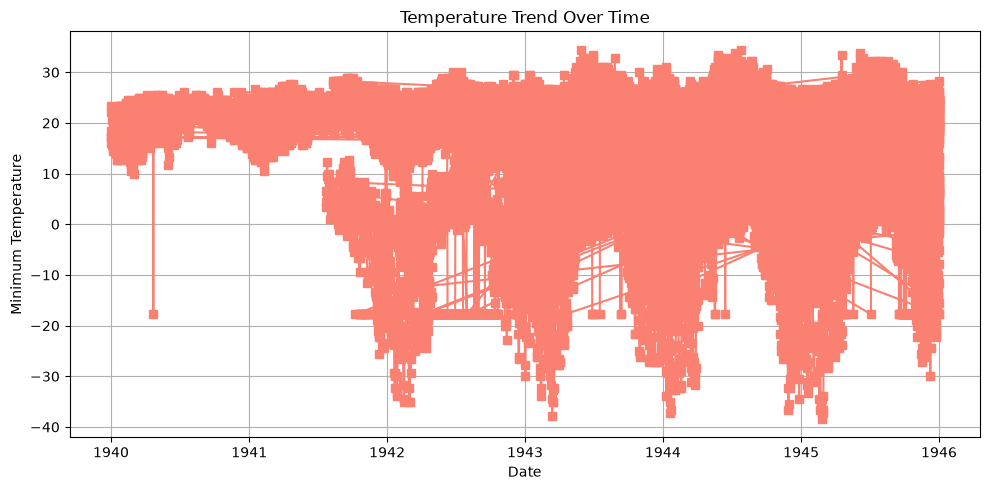

In [18]:
##Line Plot 3  (Show temperature trend over time)
plt.figure(figsize=(10,5))

plt.plot(df['Date'], df['MinTemp'], marker='s', linestyle='-', color='salmon')

plt.title('Temperature Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Minimum Temperature')

plt.grid(True)
plt.tight_layout()

plt.savefig("temperature_tend over time", 
            dpi=300,
            bbox_inches="tight")

plt.show()

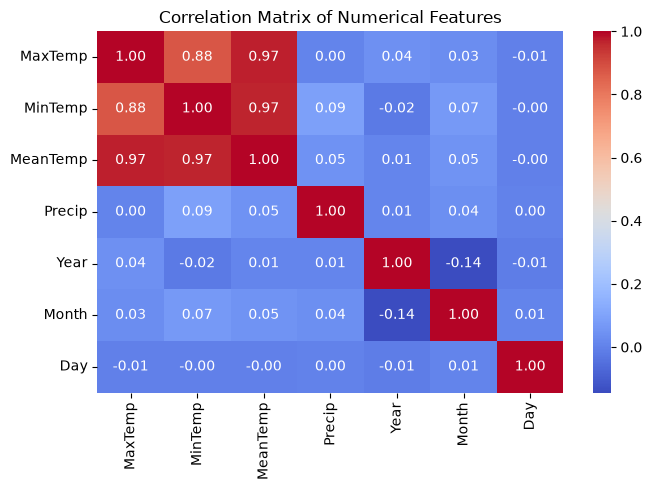

In [19]:
# Visual 3: Correlation Heatmap for Numerical Weather Features
plt.figure(figsize=(7, 5))
numerical_cols = ['MaxTemp', 'MinTemp', 'MeanTemp', 'Precip', 'Year', 'Month', 'Day']
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()

plt.savefig("Correlation Matrix of Numerical Features", 
            dpi=300, 
            bbox_inches="tight")

plt.show()

# Model Creating

## Calculate correlation for specific columns

In [107]:
correlation = df['MinTemp'].corr(df['MaxTemp'])
print("Correlation:  ", correlation)

Correlation:   0.8784084691966793


## Defining Features and Target

In [108]:
X = df[['MinTemp']]
Y = df['MaxTemp']

# Split once for both models to use
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)


## Simple  Linear Regression

In [109]:
model = LinearRegression()
model.fit(X_train, Y_train)
# Predict
Y_pred_lr = model.predict(X_test)

# Results
print("Simple Linear Regression")
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("MAE:", mean_absolute_error(Y_test, Y_pred_lr))
print("MSE:", mean_squared_error(Y_test, Y_pred_lr))
print("R² Score:", r2_score(Y_test, Y_pred_lr))

Simple Linear Regression
Intercept: 10.674491350103217
Coefficients: [0.91980088]
MAE: 3.162987745748807
MSE: 16.881147526948403
R² Score: 0.7737623092315076


# Random Forest

In [110]:
model = RandomForestRegressor()
model.fit(X_train, Y_train)
# Train model
model.fit(X_train, Y_train)

# Predict
Y_pred_rf = model.predict(X_test)

# Results
print("Random Forest Regression")
print("MAE:", mean_absolute_error(Y_test, Y_pred_rf))
print("MSE:", mean_squared_error(Y_test, Y_pred_rf))
print("R² Score:", r2_score(Y_test, Y_pred_rf))

Random Forest Regression
MAE: 2.8089390748811995
MSE: 14.23550324636803
R² Score: 0.8092186934422302


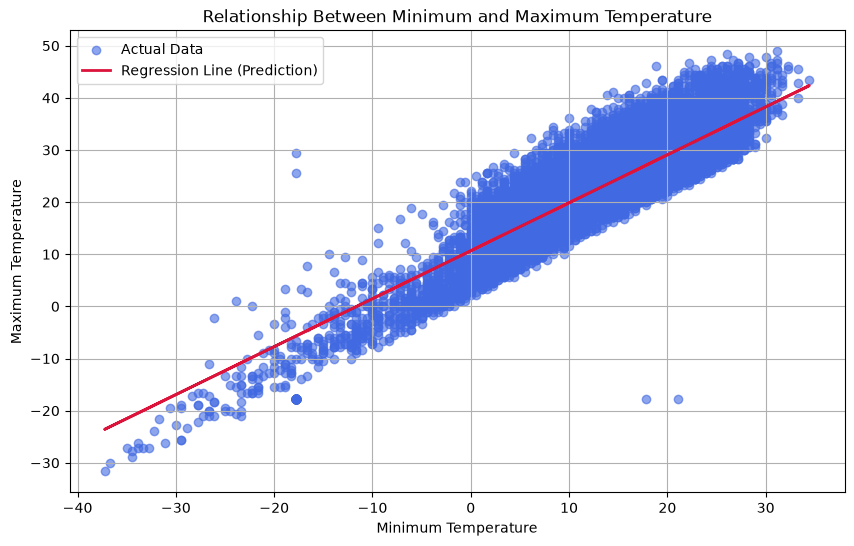

In [111]:
plt.figure(figsize=(10, 6))
plt.scatter(X_test, Y_test, color='royalblue', alpha=0.6, label='Actual Data')
plt.plot(X_test, Y_pred_lr , color='crimson', linewidth=2, label='Regression Line (Prediction)')

plt.title('Relationship Between Minimum and Maximum Temperature')
plt.xlabel('Minimum Temperature')
plt.ylabel('Maximum Temperature')
plt.legend()
plt.grid(True)

plt.savefig(
    "relationship_between_minimum_and_maximum_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [112]:
print("Final R² Accuracy Comparison")
print("Linear Regression      :", r2_score(Y_test, Y_pred_lr))
print("Random Forest          :", r2_score(Y_test, Y_pred_rf))

Final R² Accuracy Comparison
Linear Regression      : 0.7737623092315076
Random Forest          : 0.8092186934422302


In [113]:
print('Best Accuaracy is: ', r2_score(Y_test, Y_pred_rf))

Best Accuaracy is:  0.8092186934422302
